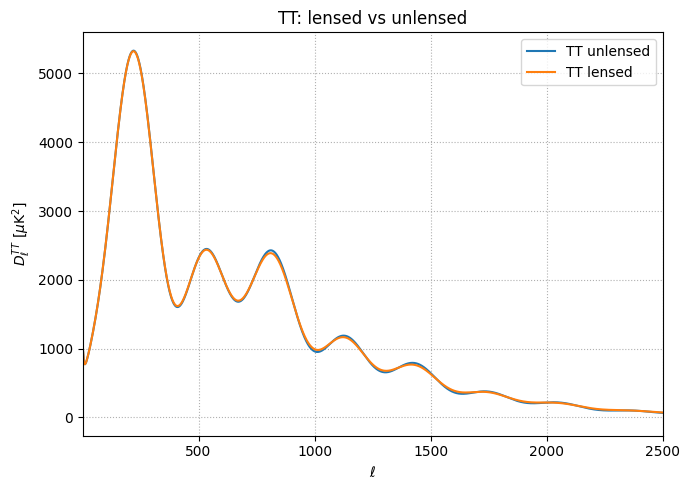

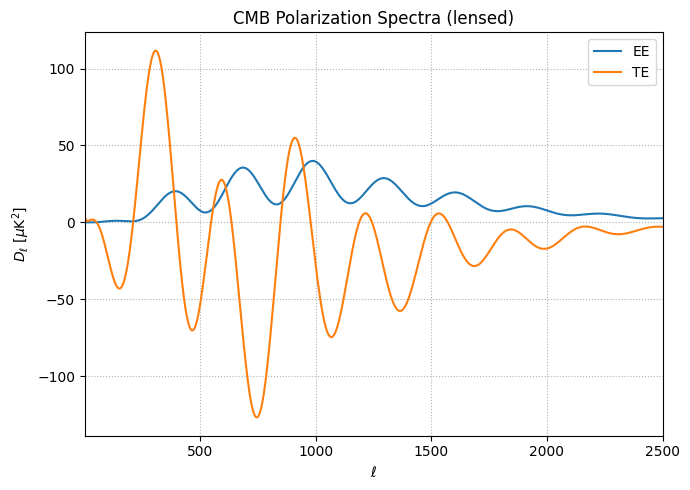

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import initialpower

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0.0, tau=0.06)
pars.InitPower.set_params(ns=0.965, As=2e-9)
pars.set_for_lmax(2500, lens_potential_accuracy=1)

results = camb.get_results(pars)

#CMB spectra 
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')

# Lensed and unlensed spectra
lensed   = powers['total']           
unlensed = powers['unlensed_scalar']

ells = np.arange(lensed.shape[0])

# TT lensed vs unlensed
plt.figure(figsize=(7,5))
plt.plot(ells, unlensed[:, 0], label="TT unlensed")
plt.plot(ells, lensed[:, 0],  label="TT lensed")
plt.xlim(2, 2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TT}\ [\mu\mathrm{K}^2]$')
plt.title('TT: lensed vs unlensed')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

#EE and TE
plt.figure(figsize=(7,5))
plt.plot(ells, lensed[:, 1], label="EE")
plt.plot(ells, lensed[:, 3], label="TE")
plt.xlim(2, 2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell\ [\mu\mathrm{K}^2]$')
plt.title('CMB Polarization Spectra (lensed)')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


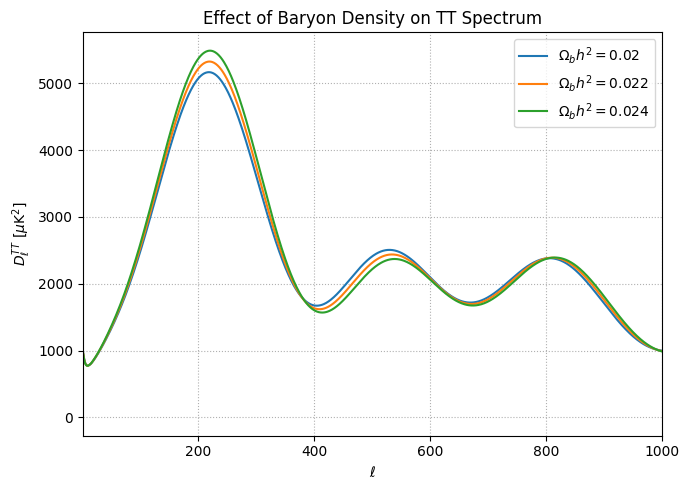

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import camb

def get_TT(ombh2):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=67.5, ombh2=ombh2, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
    pars.InitPower.set_params(ns=0.965, As=2e-9)
    pars.set_for_lmax(1000, lens_potential_accuracy=0)
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    Dl = powers['total'][:,0]
    ells = np.arange(len(Dl))
    return ells, Dl

plt.figure(figsize=(7,5))

for ombh2 in [0.020, 0.022, 0.024]:
    ells, Dl_TT = get_TT(ombh2)
    plt.plot(ells, Dl_TT, label=fr'$\Omega_b h^2={ombh2}$')

plt.xlim(2, 1000)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TT}\ [\mu\mathrm{K}^2]$')
plt.title('Effect of Baryon Density on TT Spectrum')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


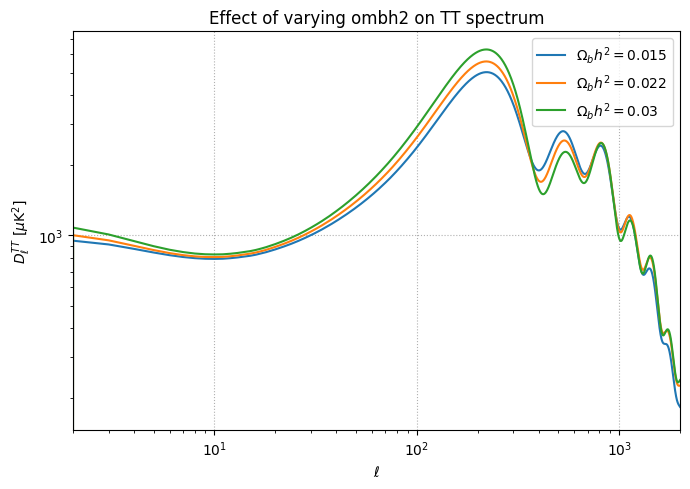

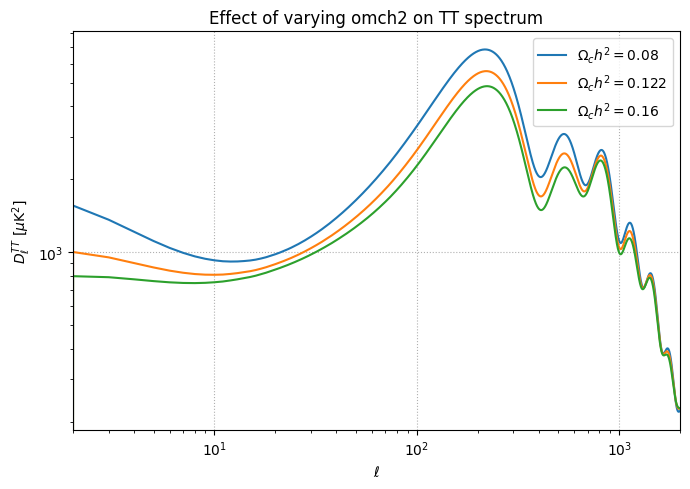

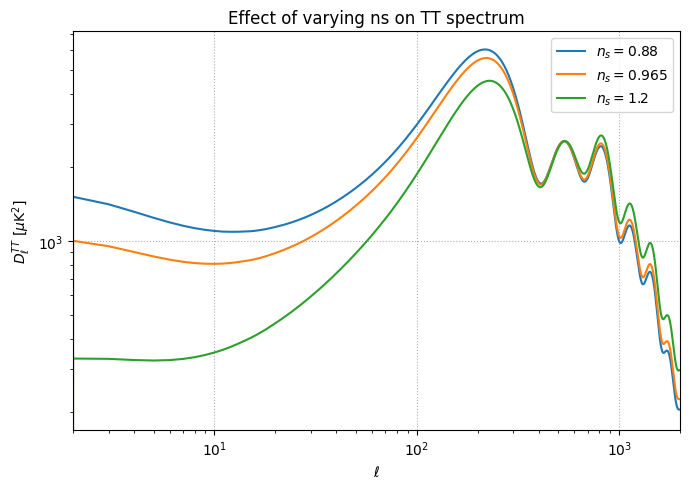

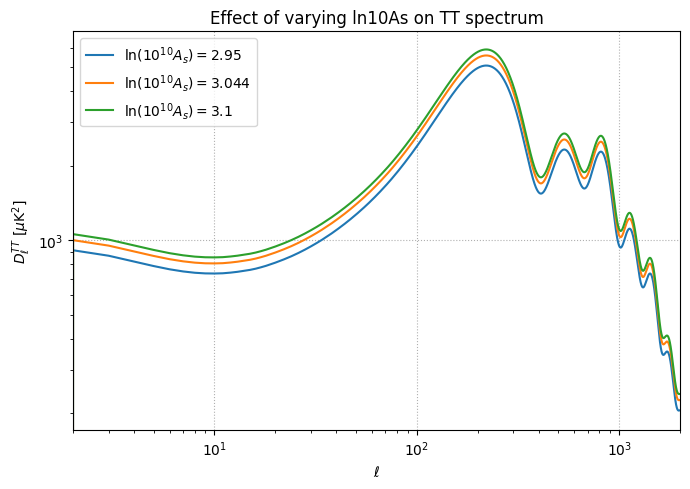

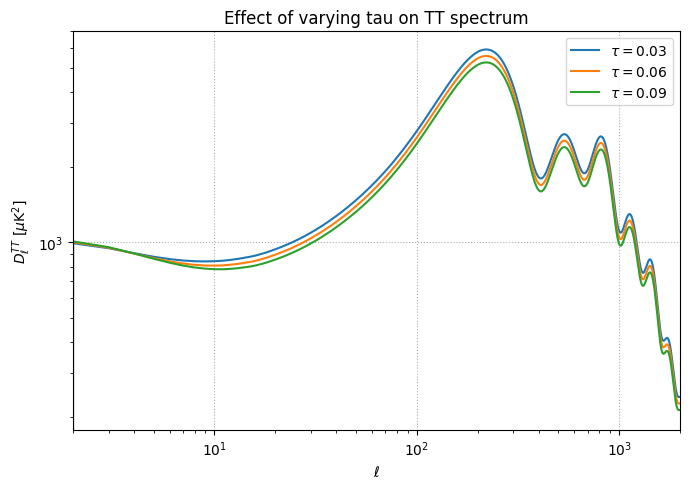

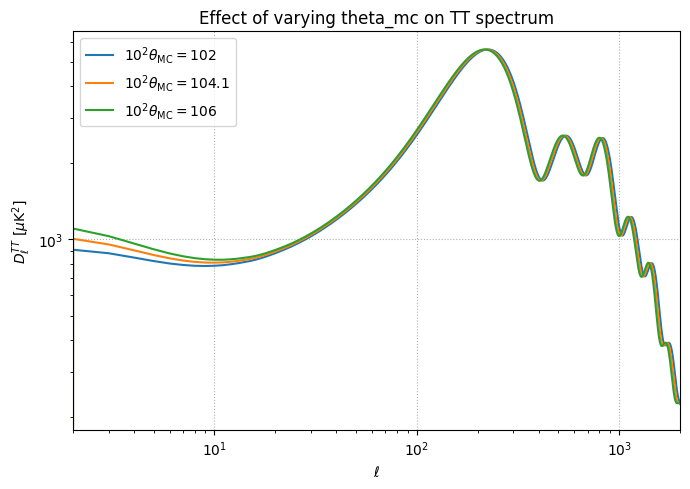

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import camb

def get_TT(theta_mc=1.041, ombh2=0.022, omch2=0.122,
           ns=0.965, ln10As=3.044, tau=0.06):
    """
    Returns ell and D_ell^TT for a given set of LambdaCDM parameters.

    Parameters
    ----------
    theta_mc : float
        100 * theta_MC approximately. CAMB uses cosmomc_theta = theta_mc/100.
    ombh2 : float
        Omega_b h^2
    omch2 : float
        Omega_c h^2
    ns : float
        Scalar spectral index
    ln10As : float
        ln(10^10 A_s)
    tau : float
        Optical depth
    """
    As = np.exp(ln10As) / 1e10

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=theta_mc / 10000.0,
        ombh2=ombh2,
        omch2=omch2,
        mnu=0.06,
        omk=0,
        tau=tau
    )
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_for_lmax(2000, lens_potential_accuracy=0)

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    Dl_TT = powers['total'][:, 0]
    ells = np.arange(len(Dl_TT))
    return ells, Dl_TT


def plot_parameter_variation(param_name, values, fiducial):
    """
    Plot TT spectra varying one parameter at a time.
    """
    plt.figure(figsize=(7, 5))

    for val in values:
        params = fiducial.copy()
        params[param_name] = val
        ells, Dl_TT = get_TT(**params)

        if param_name == "theta_mc":
            label = rf"$10^2\theta_{{\rm MC}}={val}$"
        elif param_name == "ombh2":
            label = rf"$\Omega_b h^2={val}$"
        elif param_name == "omch2":
            label = rf"$\Omega_c h^2={val}$"
        elif param_name == "ns":
            label = rf"$n_s={val}$"
        elif param_name == "ln10As":
            label = rf"$\ln(10^{{10}}A_s)={val}$"
        elif param_name == "tau":
            label = rf"$\tau={val}$"
        else:
            label = f"{param_name}={val}"

        plt.plot(ells, Dl_TT, label=label)

    plt.xlim(2, 2000)
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$D_\ell^{TT}\ [\mu\mathrm{K}^2]$')
    plt.title(f'Effect of varying {param_name} on TT spectrum')
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()
    plt.grid(True, ls=':')
    plt.tight_layout()
    plt.show()


# Fiducial LambdaCDM values
fiducial = {
    "theta_mc": 104.1,   # corresponds to 100*theta_MC
    "ombh2": 0.022,
    "omch2": 0.122,
    "ns": 0.965,
    "ln10As": 3.044,
    "tau": 0.06
}

# Example 1: vary Omega_b h^2
plot_parameter_variation("ombh2", [0.015, 0.022, 0.03], fiducial)

# Example 2: vary Omega_c h^2
plot_parameter_variation("omch2", [0.08, 0.122, 0.16], fiducial)

# Example 3: vary n_s
plot_parameter_variation("ns", [0.88, 0.965, 1.2], fiducial)

# Example 4: vary ln(10^10 A_s)
plot_parameter_variation("ln10As", [2.95, 3.044, 3.1], fiducial)

# Example 5: vary tau
plot_parameter_variation("tau", [0.03, 0.06, 0.09], fiducial)

# Example 6: vary 100*theta_MC
plot_parameter_variation("theta_mc", [102, 104.1, 106], fiducial)

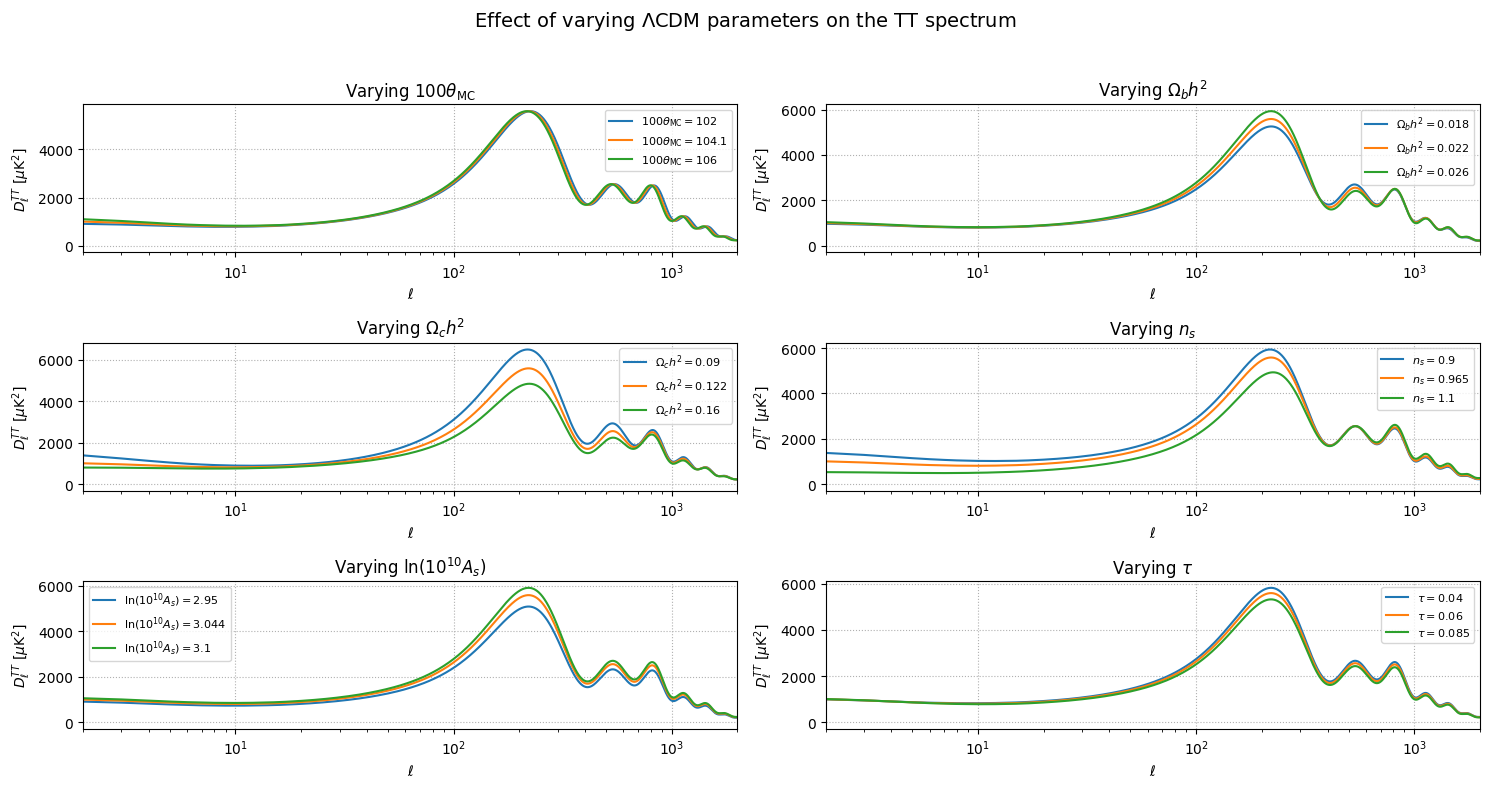

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import camb

def get_TT(theta_mc=104.1, ombh2=0.022, omch2=0.122,
           ns=0.965, ln10As=3.044, tau=0.06, lmax=2000):
    """
    Compute TT power spectrum D_ell for given LambdaCDM parameters.

    theta_mc here means 10000*theta_MC approximately.
    CAMB expects cosmomc_theta = theta_mc / 100.
    """
    As = np.exp(ln10As) / 1e10

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=theta_mc / 10000.0,
        ombh2=ombh2,
        omch2=omch2,
        mnu=0.06,
        omk=0,
        tau=tau
    )
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_for_lmax(lmax, lens_potential_accuracy=0)

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    Dl_TT = powers['total'][:, 0]
    ells = np.arange(len(Dl_TT))
    return ells, Dl_TT


# Fiducial values
fiducial = {
    "theta_mc": 104.1,
    "ombh2": 0.022,
    "omch2": 0.122,
    "ns": 0.965,
    "ln10As": 3.044,
    "tau": 0.06
}

# Values to vary for each parameter
variations = {
    "theta_mc": [102, 104.1, 106],
    "ombh2": [0.018, 0.022, 0.026],
    "omch2": [0.09, 0.122, 0.16],
    "ns": [0.90, 0.965, 1.1],
    "ln10As": [2.95, 3.044, 3.1],
    "tau": [0.04, 0.06, 0.085]
}

titles = {
    "theta_mc": r"Varying $100\theta_{\rm MC}$",
    "ombh2": r"Varying $\Omega_b h^2$",
    "omch2": r"Varying $\Omega_c h^2$",
    "ns": r"Varying $n_s$",
    "ln10As": r"Varying $\ln(10^{10}A_s)$",
    "tau": r"Varying $\tau$"
}

labels = {
    "theta_mc": lambda v: rf"$100\theta_{{\rm MC}}={v}$",
    "ombh2": lambda v: rf"$\Omega_b h^2={v}$",
    "omch2": lambda v: rf"$\Omega_c h^2={v}$",
    "ns": lambda v: rf"$n_s={v}$",
    "ln10As": lambda v: rf"$\ln(10^{{10}}A_s)={v}$",
    "tau": lambda v: rf"$\tau={v}$"
}

# Make a 2x3 figure
fig, axes = plt.subplots(3, 2, figsize=(15, 8))
axes = axes.flatten()

for ax, param in zip(axes, variations.keys()):
    for val in variations[param]:
        params = fiducial.copy()
        params[param] = val
        ells, Dl_TT = get_TT(**params)
        ax.plot(ells, Dl_TT, label=labels[param](val))

    ax.set_xlim(2, 2000)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell^{TT}\ [\mu\mathrm{K}^2]$')
    ax.set_title(titles[param])
    ax.set_xscale("log")
    ax.grid(True, ls=':')
    ax.legend(fontsize=8)
    
    #if param in ["ln10As", "theta_mc","tau"]:
    #    ax.set_yscale("log")
    #else:
    #    ax.set_xscale("log")

fig.suptitle(r'Effect of varying $\Lambda$CDM parameters on the TT spectrum', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save everything to one-page PDF
plt.savefig("lcdm_parameter_variations.pdf", format="pdf", bbox_inches="tight")
plt.show()

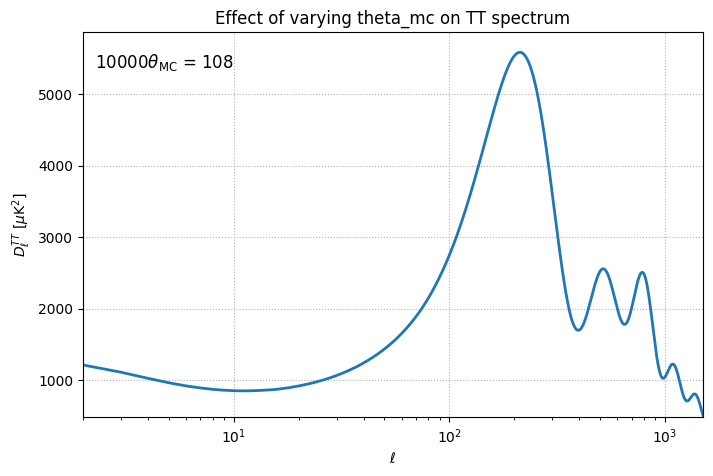

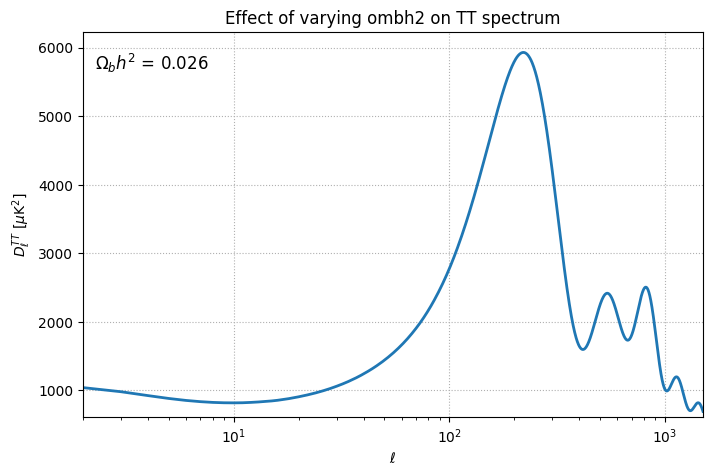

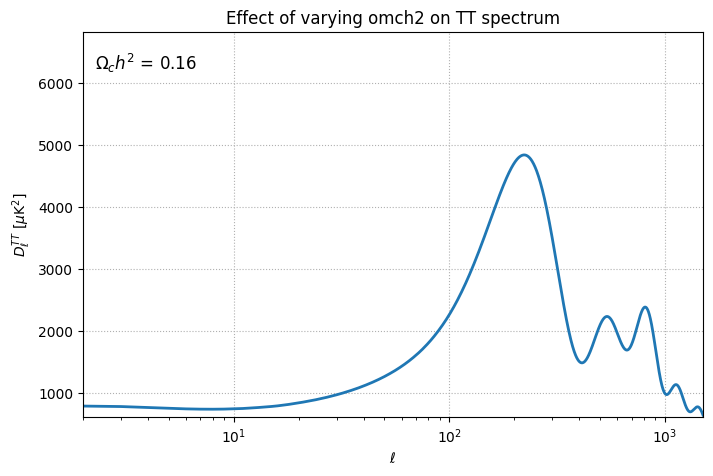

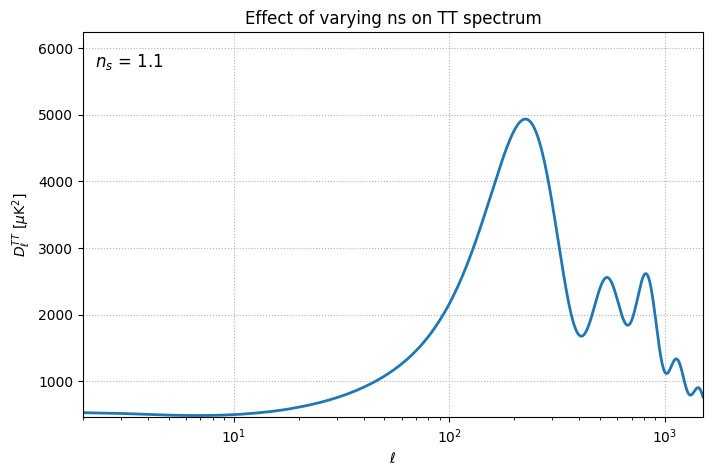

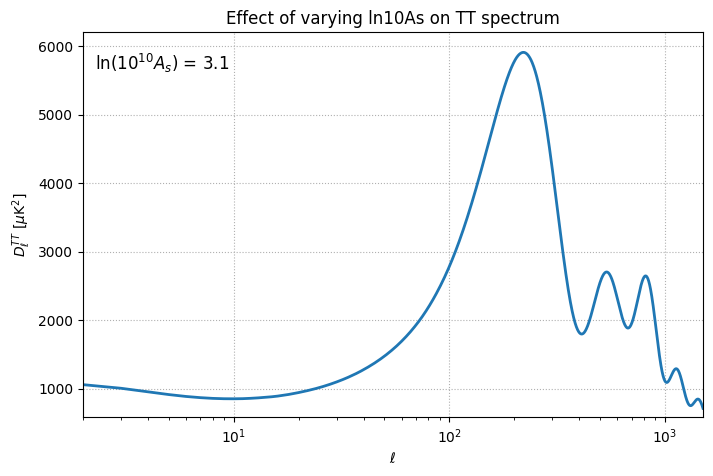

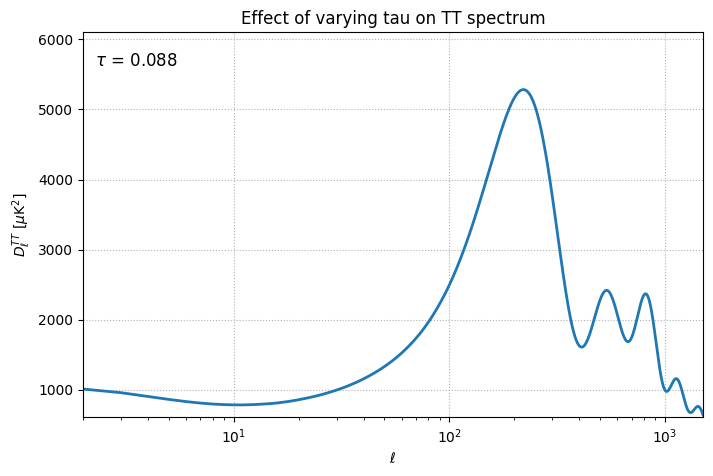

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import camb


def get_TT(theta_mc=104.1, ombh2=0.022, omch2=0.122,
           ns=0.965, ln10As=3.044, tau=0.06, lmax=1500):
    As = np.exp(ln10As) / 1e10

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=theta_mc / 10000.0,
        ombh2=ombh2,
        omch2=omch2,
        mnu=0.06,
        omk=0,
        tau=tau
    )
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_for_lmax(lmax, lens_potential_accuracy=0)

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    Dl_TT = powers['total'][:, 0]
    ells = np.arange(len(Dl_TT))
    return ells, Dl_TT


# Fiducial LambdaCDM values
fiducial = {
    "theta_mc": 104.1,
    "ombh2": 0.022,
    "omch2": 0.122,
    "ns": 0.965,
    "ln10As": 3.044,
    "tau": 0.06
}

labels = {
    "theta_mc": r"$10000\theta_{\rm MC}$",
    "ombh2": r"$\Omega_b h^2$",
    "omch2": r"$\Omega_c h^2$",
    "ns": r"$n_s$",
    "ln10As": r"$\ln(10^{10}A_s)$",
    "tau": r"$\tau$"
}


def animate_parameter(param_name, values, fiducial, filename=None, ylog=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], lw=2)
    text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top", fontsize=12)

    # Precompute spectra so animation is smoother
    spectra = []
    for val in values:
        params = fiducial.copy()
        params[param_name] = val
        ells, Dl = get_TT(**params)
        spectra.append((val, ells, Dl))

    # Set fixed axis limits
    all_y = np.concatenate([Dl[2:1501] for _, _, Dl in spectra])
    ax.set_xlim(2, 1500)
    ax.set_ylim(all_y.min() * 0.95, all_y.max() * 1.05)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell^{TT}\ [\mu\mathrm{K}^2]$')
    ax.set_title(f"Effect of varying {param_name} on TT spectrum")
    ax.set_xscale("log")
    ax.grid(True, ls=':')

    if ylog:
        ax.set_yscale("log")

    def init():
        line.set_data([], [])
        text.set_text("")
        return line, text

    def update(frame):
        val, ells, Dl = spectra[frame]
        line.set_data(ells[2:1501], Dl[2:1501])
        text.set_text(f"{labels[param_name]} = {val:.5g}")
        return line, text

    anim = FuncAnimation(
        fig, update, frames=len(spectra),
        init_func=init, blit=True, interval=200
    )

    if filename is not None:
        anim.save(filename, writer=PillowWriter(fps=8))

    plt.show()
    return anim


animate_parameter("theta_mc", np.linspace(100, 108, 40), fiducial, "theta_mc.gif")
animate_parameter("ombh2",   np.linspace(0.018, 0.026, 40), fiducial, "ombh2.gif")
animate_parameter("omch2",   np.linspace(0.09, 0.16, 40), fiducial, "omch2.gif")
animate_parameter("ns",      np.linspace(0.90, 1.1, 40), fiducial, "ns.gif")
animate_parameter("ln10As",  np.linspace(2.95, 3.10, 40), fiducial, "ln10As.gif")
animate_parameter("tau",     np.linspace(0.04, 0.088, 40), fiducial, "tau.gif")